In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

## Load the Cleaned Dataset

In [2]:
df = pd.read_csv(r"C:\Users\BluRay\OneDrive\Desktop\BankingCustomerAnalysis\credit_card_customers_cleaned.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.shape

(8950, 18)

## Remove the Customer ID Column

In [4]:
df = df.drop("CUST_ID", axis=1)

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Check Feature Skewness


In [5]:
df.skew().sort_values(ascending=False)

MINIMUM_PAYMENTS                    13.852446
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522636
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64

In [6]:
#Apply Log Transformation (Reduce Skewness)
skewness = df.skew()

skewed_features = skewness[abs(skewness) > 1].index

skewed_features


for col in skewed_features:
    df[col] = np.log1p(df[col])

In [7]:
#Check skewness again:
df.skew().sort_values(ascending=False)

PRC_FULL_PAYMENT                    1.746046
CASH_ADVANCE_FREQUENCY              1.455462
ONEOFF_PURCHASES_FREQUENCY          1.290617
CASH_ADVANCE_TRX                    0.940131
PURCHASES_INSTALLMENTS_FREQUENCY    0.509201
MINIMUM_PAYMENTS                    0.269703
CASH_ADVANCE                        0.262594
ONEOFF_PURCHASES                    0.185854
PURCHASES_FREQUENCY                 0.060164
PURCHASES_TRX                       0.032697
INSTALLMENTS_PURCHASES             -0.024981
CREDIT_LIMIT                       -0.101408
PURCHASES                          -0.764492
BALANCE                            -0.861021
PAYMENTS                           -1.778312
BALANCE_FREQUENCY                  -2.285534
TENURE                             -3.170222
dtype: float64

## Visualize Feature Distributions

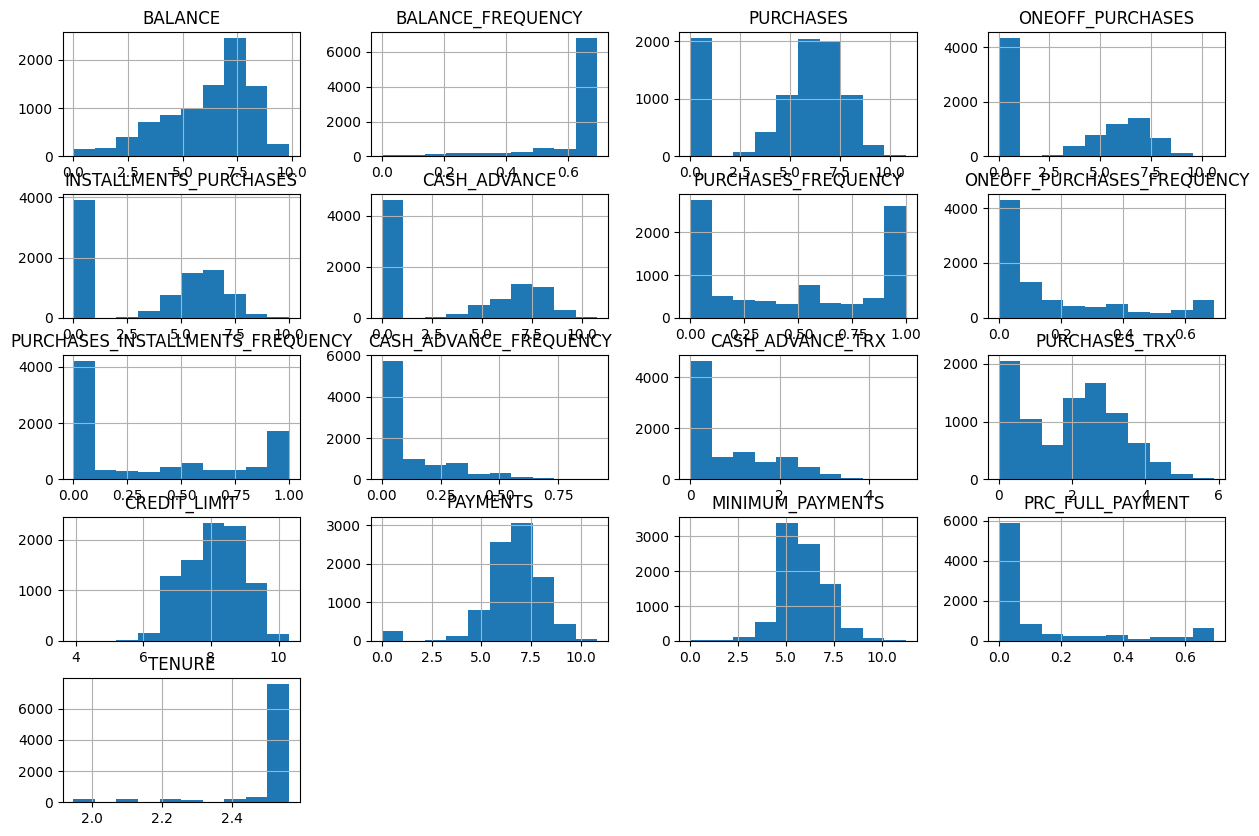

In [8]:
df.hist(figsize=(15,10))
plt.show()

## Feature Scaling

In [9]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

## Convert Back to DataFrame

In [10]:
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205218,-0.148757,-0.113532,-0.987090,0.394480,-0.930733,-0.806490,-0.732480,-0.707313,-0.724360,-0.810069,-0.579510,-1.447163,-0.824484,-0.829841,-0.556368,0.347262
1,0.948918,0.179616,-1.679855,-0.987090,-1.087454,1.528788,-1.221758,-0.732480,-0.916995,0.699592,0.784603,-1.379210,0.926060,1.065033,0.908184,0.391958,0.347262
2,0.824993,0.492710,0.600727,1.062022,-1.087454,-0.930733,1.269843,2.466762,-0.916995,-0.724360,-0.810069,0.487865,1.010229,-0.119300,0.450407,-0.556368,0.347262
3,0.624653,-0.857867,0.827499,1.265778,-1.087454,0.564372,-1.014125,-0.363042,-0.916995,-0.213583,-0.123281,-0.874655,1.010229,-4.161996,-0.144271,-0.556368,0.347262
4,0.271260,0.492710,-0.708481,-0.114307,-1.087454,-0.930733,-1.014125,-0.363042,-0.916995,-0.724360,-0.810069,-0.874655,-1.224909,-0.064979,-0.351833,-0.556368,0.347262


## Verify the Scaling

In [11]:
df_scaled.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8.950000e+03,8.950000e+03,8950.000000,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03
mean,0.000000,-2.826293e-16,6.986342e-17,0.000000,1.034058e-16,6.668781e-17,9.328354e-17,3.810732e-17,5.716098e-17,-1.667195e-17,-5.795488e-17,1.397268e-16,-5.462049e-16,3.493171e-16,-2.159415e-16,-5.080976e-17,1.422673e-15
std,1.000056,1.000056e+00,1.000056e+00,1.000056,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00
min,-3.060633,-4.172393e+00,-1.679855e+00,-0.987090,-1.087454e+00,-9.307329e-01,-1.221758e+00,-7.324800e-01,-9.169952e-01,-7.243604e-01,-8.100687e-01,-1.379210e+00,-5.079410e+00,-4.161996e+00,-5.040840e+00,-5.563681e-01,-4.401425e+00
25%,-0.645563,1.080159e-01,-4.097152e-01,-0.987090,-1.087454e+00,-9.307329e-01,-1.014125e+00,-7.324800e-01,-9.169952e-01,-7.243604e-01,-8.100687e-01,-8.746552e-01,-8.741531e-01,-4.229376e-01,-6.576937e-01,-5.563681e-01,3.472622e-01
50%,0.303937,4.927100e-01,3.403734e-01,0.141485,3.721960e-01,-9.307329e-01,2.404259e-02,-3.630419e-01,-4.976286e-01,-7.243604e-01,-8.100687e-01,1.344545e-01,-1.075230e-01,8.164312e-02,-1.442709e-01,-5.563681e-01,3.472622e-01
75%,0.728427,4.927100e-01,7.246132e-01,0.972218,9.081215e-01,1.036809e+00,1.062211e+00,4.784703e-01,9.701506e-01,5.561843e-01,7.846025e-01,7.247459e-01,8.356521e-01,5.818980e-01,6.458797e-01,7.467219e-02,3.472622e-01
max,1.834341,4.927100e-01,2.023087e+00,2.283062,2.163264e+00,2.086805e+00,1.269843e+00,2.466762e+00,1.599199e+00,5.122793e+00,3.965987e+00,2.903371e+00,2.701570e+00,2.644753e+00,4.554165e+00,2.719298e+00,3.472622e-01


## Save the Dataset for Clustering

In [12]:
df_scaled.to_csv("C:\\Users\\BluRay\\OneDrive\\Desktop\\BankingCustomerAnalysis\\credit_card_customers_scaled.csv", index=False)

## Feature Engineering Summary

This notebook prepares financial features for machine learning analysis.

The following transformations were applied:

• Removed non-predictive identifier variables
• Analyzed feature skewness
• Applied logarithmic transformation to highly skewed financial variables
• Standardized numerical features using StandardScaler

The resulting dataset is normalized and suitable for clustering algorithms used in customer segmentation.
